In [1]:
import kagglehub
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
import cv2 


In [ ]:
path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset")


path 

In [ ]:
# path = r"C:\\Users\\idjaf\\.cache\\kagglehub\\datasets\\aryashah2k\\breast-ultrasound-images-dataset\\versions\\1"

In [4]:
Dataset_BUSI_with_GT = os.listdir(path)
path2 = os.path.join(path , Dataset_BUSI_with_GT[0])
# type(Dataset_BUSI_with_GT[0])
print(f"path2:{path2}")
os.listdir(path2)


path2:C:\\Users\\idjaf\\.cache\\kagglehub\\datasets\\aryashah2k\\breast-ultrasound-images-dataset\\versions\\1\Dataset_BUSI_with_GT


['benign', 'malignant', 'normal']

In [5]:
def get_main_image(folder_path):
    all_files = os.listdir(folder_path)
    main_images = [f for f in all_files if 'mask' not in f]
    return main_images

In [6]:
benign_path = os.path.join(path2 , "benign")
main_imgs_benign = get_main_image(benign_path)

len_main_images_benign: 437
True
benign (130).png


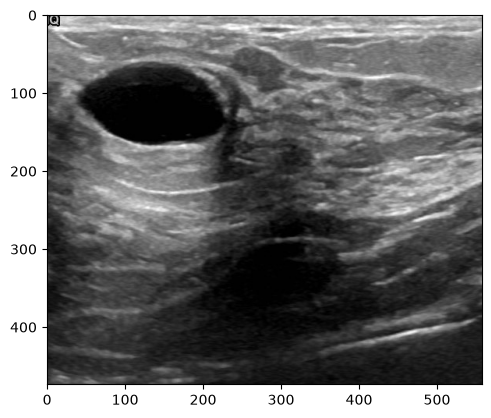

In [7]:
print("len_main_images_benign:",len(main_imgs_benign))
print('benign (2).png' in main_imgs_benign)

plt.close()
img = plt.imread(os.path.join(benign_path , main_imgs_benign[35]))
plt.imshow(img)
print(main_imgs_benign[35])

In [8]:
def get_masks_for_image(folder_path , image_name):
    base_name = image_name.replace(".png" , "")
    all_files = os.listdir(folder_path)
    mask = [f for f in all_files if f.startswith(base_name + "_mask")]
    return mask

In [9]:
for img in main_imgs_benign:
    masks = get_masks_for_image(benign_path, img)
    if len(masks) > 1:
        print(img, masks)

benign (100).png ['benign (100)_mask.png', 'benign (100)_mask_1.png']
benign (163).png ['benign (163)_mask.png', 'benign (163)_mask_1.png']
benign (173).png ['benign (173)_mask.png', 'benign (173)_mask_1.png']
benign (181).png ['benign (181)_mask.png', 'benign (181)_mask_1.png']
benign (195).png ['benign (195)_mask.png', 'benign (195)_mask_1.png', 'benign (195)_mask_2.png']
benign (25).png ['benign (25)_mask.png', 'benign (25)_mask_1.png']
benign (315).png ['benign (315)_mask.png', 'benign (315)_mask_1.png']
benign (346).png ['benign (346)_mask.png', 'benign (346)_mask_1.png']
benign (4).png ['benign (4)_mask.png', 'benign (4)_mask_1.png']
benign (424).png ['benign (424)_mask.png', 'benign (424)_mask_1.png']
benign (54).png ['benign (54)_mask.png', 'benign (54)_mask_1.png']
benign (58).png ['benign (58)_mask.png', 'benign (58)_mask_1.png']
benign (83).png ['benign (83)_mask.png', 'benign (83)_mask_1.png']
benign (92).png ['benign (92)_mask.png', 'benign (92)_mask_1.png']
benign (93).pn

In [10]:
def merge_masks(folder_path, mask_filenames, image_path=None):
    combined = None
    for mask_name in mask_filenames:
        mask_path = os.path.join(folder_path, mask_name)
        mask_img = Image.open(mask_path).convert('L')
        mask_array = np.array(mask_img)
        if combined is None:
            combined = mask_array
        else:
            combined = np.maximum(combined, mask_array)
    if combined is None:
        ref_img = Image.open(image_path).convert('L')
        combined = np.zeros(np.array(ref_img).shape, dtype=np.uint8)
    return combined

In [11]:
masks_100 = get_masks_for_image(benign_path, 'benign (100).png')
merged_100 = merge_masks(benign_path, masks_100)
print(merged_100.shape)
print(np.unique(merged_100))

(473, 323)
[  0 255]


In [12]:
masks_100
m = os.path.join(benign_path , masks_100[0])
img = cv2.imread(m) 
m2 = os.path.join(benign_path , masks_100[1])
img2 = cv2.imread(m2)
line_width = 5
separator = np.full((img.shape[0], line_width, 3), (0, 0, 255), dtype=np.uint8)
yy = cv2.hconcat([img , separator , img2])
cv2.imshow("im" , yy)
cv2.waitKey(0)
cv2.destroyAllWindows()

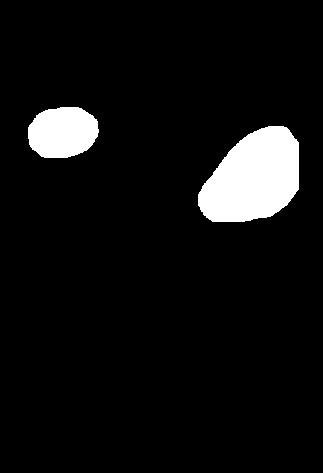

In [13]:
img  = Image.fromarray(merged_100)

img

In [14]:
def build_dataset_for_folder(folder_path):
    main_images = get_main_image(folder_path)
    data_pairs = []
    for img_name in main_images:
        img_path = os.path.join(folder_path, img_name)
        masks = get_masks_for_image(folder_path, img_name)
        merged_mask = merge_masks(folder_path, masks, image_path=img_path)
        data_pairs.append((img_path, merged_mask))
    return data_pairs

In [15]:
normal_path = os.path.join(path2, 'normal')
data_normal = build_dataset_for_folder(normal_path)
print(len(data_normal))
print(data_normal[0][0])
print(np.unique(data_normal[0][1]))

133
C:\\Users\\idjaf\\.cache\\kagglehub\\datasets\\aryashah2k\\breast-ultrasound-images-dataset\\versions\\1\Dataset_BUSI_with_GT\normal\normal (1).png
[0]


In [16]:
benign_path = os.path.join(path2, 'benign')
malignant_path = os.path.join(path2, 'malignant')
normal_path = os.path.join(path2, 'normal')

data_benign = build_dataset_for_folder(benign_path)
data_malignant = build_dataset_for_folder(malignant_path)
data_normal = build_dataset_for_folder(normal_path)

all_data = data_benign + data_malignant + data_normal
print(len(all_data))

780


In [17]:
IMG_SIZE = 128

def binarize_mask(mask_array, threshold=127):
    binary_mask = (mask_array > threshold).astype(np.uint8)
    return binary_mask

In [18]:
def load_and_resize(img_path, mask_array, size=IMG_SIZE):
    img = Image.open(img_path).convert('L')
    img = img.resize((size, size))
    img_array = np.array(img)

    mask_img = Image.fromarray(mask_array)
    mask_img = mask_img.resize((size, size))
    mask_resized = np.array(mask_img)
    mask_binary = binarize_mask(mask_resized)

    return img_array, mask_binary

In [19]:
sample_img_path, sample_mask_array = all_data[0]
img_resized, mask_resized = load_and_resize(sample_img_path, sample_mask_array)

print(img_resized.shape)
print(mask_resized.shape)
print(np.unique(mask_resized))

(128, 128)
(128, 128)
[0 1]


In [20]:
X = []
Y = []

for img_path, mask_array in all_data:
    img_resized, mask_binary = load_and_resize(img_path, mask_array)
    X.append(img_resized)
    Y.append(mask_binary)

X = np.array(X)
Y = np.array(Y)

print(X.shape)
print(Y.shape)

(780, 128, 128)
(780, 128, 128)


In [21]:
X = X.astype(np.float32) / 255.0
Y = Y.astype(np.float32)

X = np.expand_dims(X, axis=-1)
Y = np.expand_dims(Y, axis=-1)

print(X.shape)
print(Y.shape)
print(X.min(), X.max())
print(Y.min(), Y.max())

(780, 128, 128, 1)
(780, 128, 128, 1)
0.0 1.0
0.0 1.0


In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(624, 128, 128, 1) (156, 128, 128, 1)
(624, 128, 128, 1) (156, 128, 128, 1)


In [23]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    return x

In [24]:
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

c1 = conv_block(inputs, 16)
p1 = layers.MaxPooling2D(2)(c1)

c2 = conv_block(p1, 32)
p2 = layers.MaxPooling2D(2)(c2)

c3 = conv_block(p2, 64)
p3 = layers.MaxPooling2D(2)(c3)

c4 = conv_block(p3, 128)
p4 = layers.MaxPooling2D(2)(c4)

b = conv_block(p4, 256)

u1 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(b)
u1 = layers.Concatenate()([u1, c4])
c5 = conv_block(u1, 128)

u2 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c5)
u2 = layers.Concatenate()([u2, c3])
c6 = conv_block(u2, 64)

u3 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(c6)
u3 = layers.Concatenate()([u3, c2])
c7 = conv_block(u3, 32)

u4 = layers.Conv2DTranspose(16, 2, strides=2, padding='same')(c7)
u4 = layers.Concatenate()([u4, c1])
c8 = conv_block(u4, 16)

In [25]:
outputs = layers.Conv2D(1, 1, activation='sigmoid')(c8)

model = models.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 128) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 256) │    295,168 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8, 256) │    590,080 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    131,200 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,940,817 (7.40 MB)

 Trainable params: 1,940,817 (7.40 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [27]:
# history = model.fit(
#     X_train, Y_train,
#     validation_data=(X_test, Y_test),
#     epochs=30,
#     batch_size=16
# )
model = load_model("breast_camcer_model.weight.h5")



In [28]:
loss , acc = model.evaluate(X_test , Y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 476ms/step - accuracy: 0.9586 - loss: 0.1510


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step


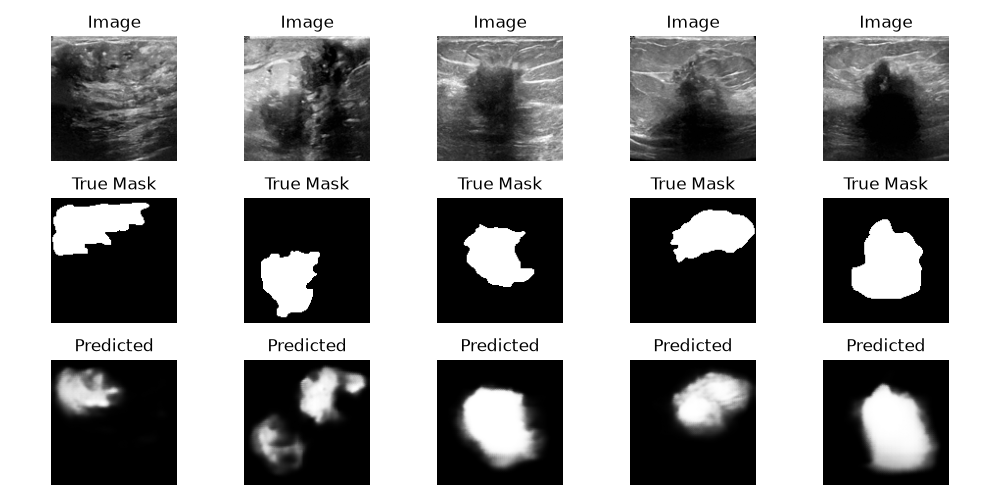

In [40]:
%matplotlib widget
predictions = model.predict(X_test[:5])

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title('Image')
    plt.axis('off')

    plt.subplot(3, 5, i + 6)
    plt.imshow(Y_test[i], cmap='gray')
    plt.title('True Mask')
    plt.axis('off')

    plt.subplot(3, 5, i + 11)
    plt.imshow(predictions[i], cmap='gray')
    plt.title('Predicted')
    plt.axis('off')



plt.tight_layout()
plt.show()
# Y_test[0].shape

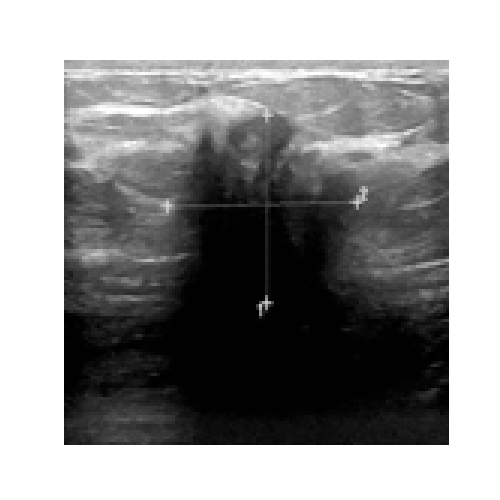

In [ ]:
plt.close()
plt.figure(figsize=(5 , 5))
plt.imshow(X_test[100].squeeze(), cmap='gray')
plt.axis('off')
plt.show()

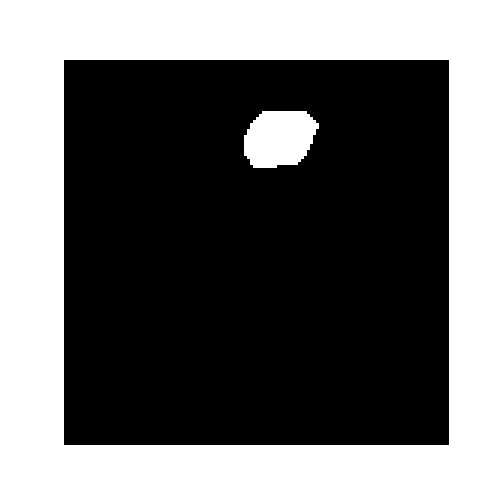

In [33]:
plt.figure(figsize=(5 , 5))
plt.imshow(Y_test[15].squeeze(), cmap='gray')
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 642ms/step


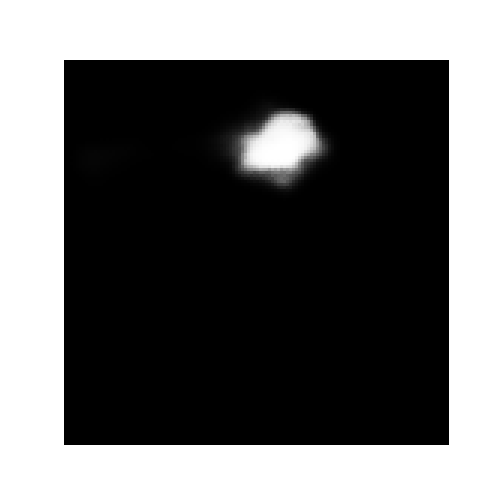

In [34]:
per = model.predict(X_test[15].reshape(-1 , 128 , 128 , 1))
plt.close()
plt.imshow(per.squeeze() , cmap="gray")
plt.show()

In [35]:
# model.save("breast_camcer_model.weight.h5")

In [36]:
predictions2 = model.predict(X_test)

for idx in range(len(X_test)):
    img = (X_test[idx].squeeze() * 255).astype(np.uint8)
    true_mask = (Y_test[idx].squeeze() * 255).astype(np.uint8)
    pred_mask = (predictions2[idx].squeeze() * 255).astype(np.uint8)

    combined = cv2.hconcat([img, true_mask, pred_mask])

    cv2.imshow('Image | True Mask | Predicted', combined)
    key = cv2.waitKey(0)
    if key == 27: 
        break

cv2.destroyAllWindows()

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 408ms/step
